# 🏧 Loan Eligibility Prediction 💰 using Machine Learning Models 🤖

## In this notebook kernal, I'm going to predictions customers are eligible for the loan and check whether what are the missing criteria to know why customer not getting loan to make there own house.

## Steps are :
#Loading data  
#Exploratory Data Analysis
Data Visualizations
Machine Learning Model Decision.
Traing the ML Model
Predict Model
Accuracy check

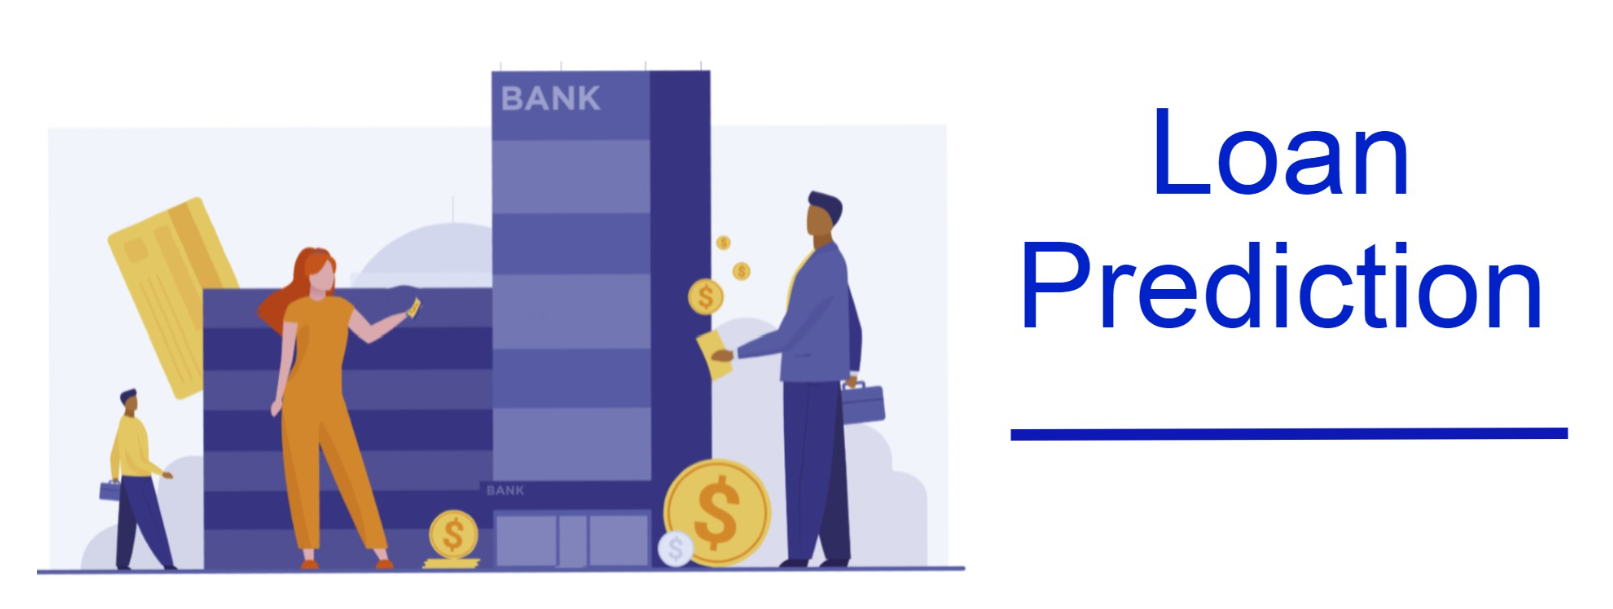

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

## Importing & Loading the dataset

In [2]:
df_train = pd.read_csv('loan-train.csv')
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df_test= pd.read_csv('loan-test.csv')
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


## Dataset Info:

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Dataset Shape:

In [5]:
df_train.shape

(614, 13)

In [6]:
df_train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Data Cleaning

### Checking the Missing Values

In [7]:
df_train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### First we will fill the Missing Numerical column  by the 'Mean' & 'Mode' of the respective variables.

In [8]:
df_train['Credit_History'].fillna(df_train['Credit_History'].mode(), inplace=True) 
df_test['Credit_History'].fillna(df_test['Credit_History'].mode(), inplace=True) 


df_train['LoanAmount'].fillna(df_train['LoanAmount'].mean(), inplace=True) 
df_test['LoanAmount'].fillna(df_test['LoanAmount'].mean(), inplace=True) 

### Converting Categorical variable with Numerical values.

Loan_Status feature boolean values, So we replace Y values with 1 and N values with 0 and same for other Boolean types of columns

In [9]:
df_train.Loan_Status = df_train.Loan_Status.replace({"Y": 1, "N" : 0})

df_train.Gender = df_train.Gender.replace({"Male": 1, "Female" : 0})
df_test.Gender = df_test.Gender.replace({"Male": 1, "Female" : 0})

df_train.Married = df_train.Married.replace({"Yes": 1, "No" : 0})
df_test.Married = df_test.Married.replace({"Yes": 1, "No" : 0})

df_train.Self_Employed = df_train.Self_Employed.replace({"Yes": 1, "No" : 0})
df_test.Self_Employed = df_test.Self_Employed.replace({"Yes": 1, "No" : 0})

### Now again converting all values with mode

In [10]:
df_train['Gender'].fillna(df_train['Gender'].mode()[0], inplace=True)
df_test['Gender'].fillna(df_test['Gender'].mode()[0], inplace=True)

df_train['Dependents'].fillna(df_train['Dependents'].mode()[0], inplace=True)
df_test['Dependents'].fillna(df_test['Dependents'].mode()[0], inplace=True)

df_train['Married'].fillna(df_train['Married'].mode()[0], inplace=True)
df_test['Married'].fillna(df_test['Married'].mode()[0], inplace=True)

df_train['Credit_History'].fillna(df_train['Credit_History'].mean(), inplace=True)
df_test['Credit_History'].fillna(df_test['Credit_History'].mean(), inplace=True)

In [11]:
df_train.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
df_test.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      6
Credit_History        0
Property_Area         0
dtype: int64

#### Here, Property_Area, Dependents and Education has multiple values so now we can use LabelEncoder from sklearn package

In [13]:
from sklearn.preprocessing import LabelEncoder
feature_col = ['Property_Area','Education', 'Dependents']
le = LabelEncoder()
for col in feature_col:
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.fit_transform(df_test[col])

#### Now, Let's drop all the missing values remaining.

In [14]:
df_train.dropna(inplace=True)

In [15]:
df_test.dropna(inplace=True)

#### Now lets finally check our dataset have any missing term or not

In [16]:
df_train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
df_test.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

##### Here, we have dropped all the missing values to avoid disturbances in the model. The Loan Prediction requires all the details to work efficiently and thus the missing values are dropped.

### Now, Let's check the final Dataset Shape

In [18]:
df_train.shape

(569, 13)

## Data Visualizations

### Comparison between Parameters in getting the Loan:

<AxesSubplot:xlabel='Property_Area', ylabel='count'>

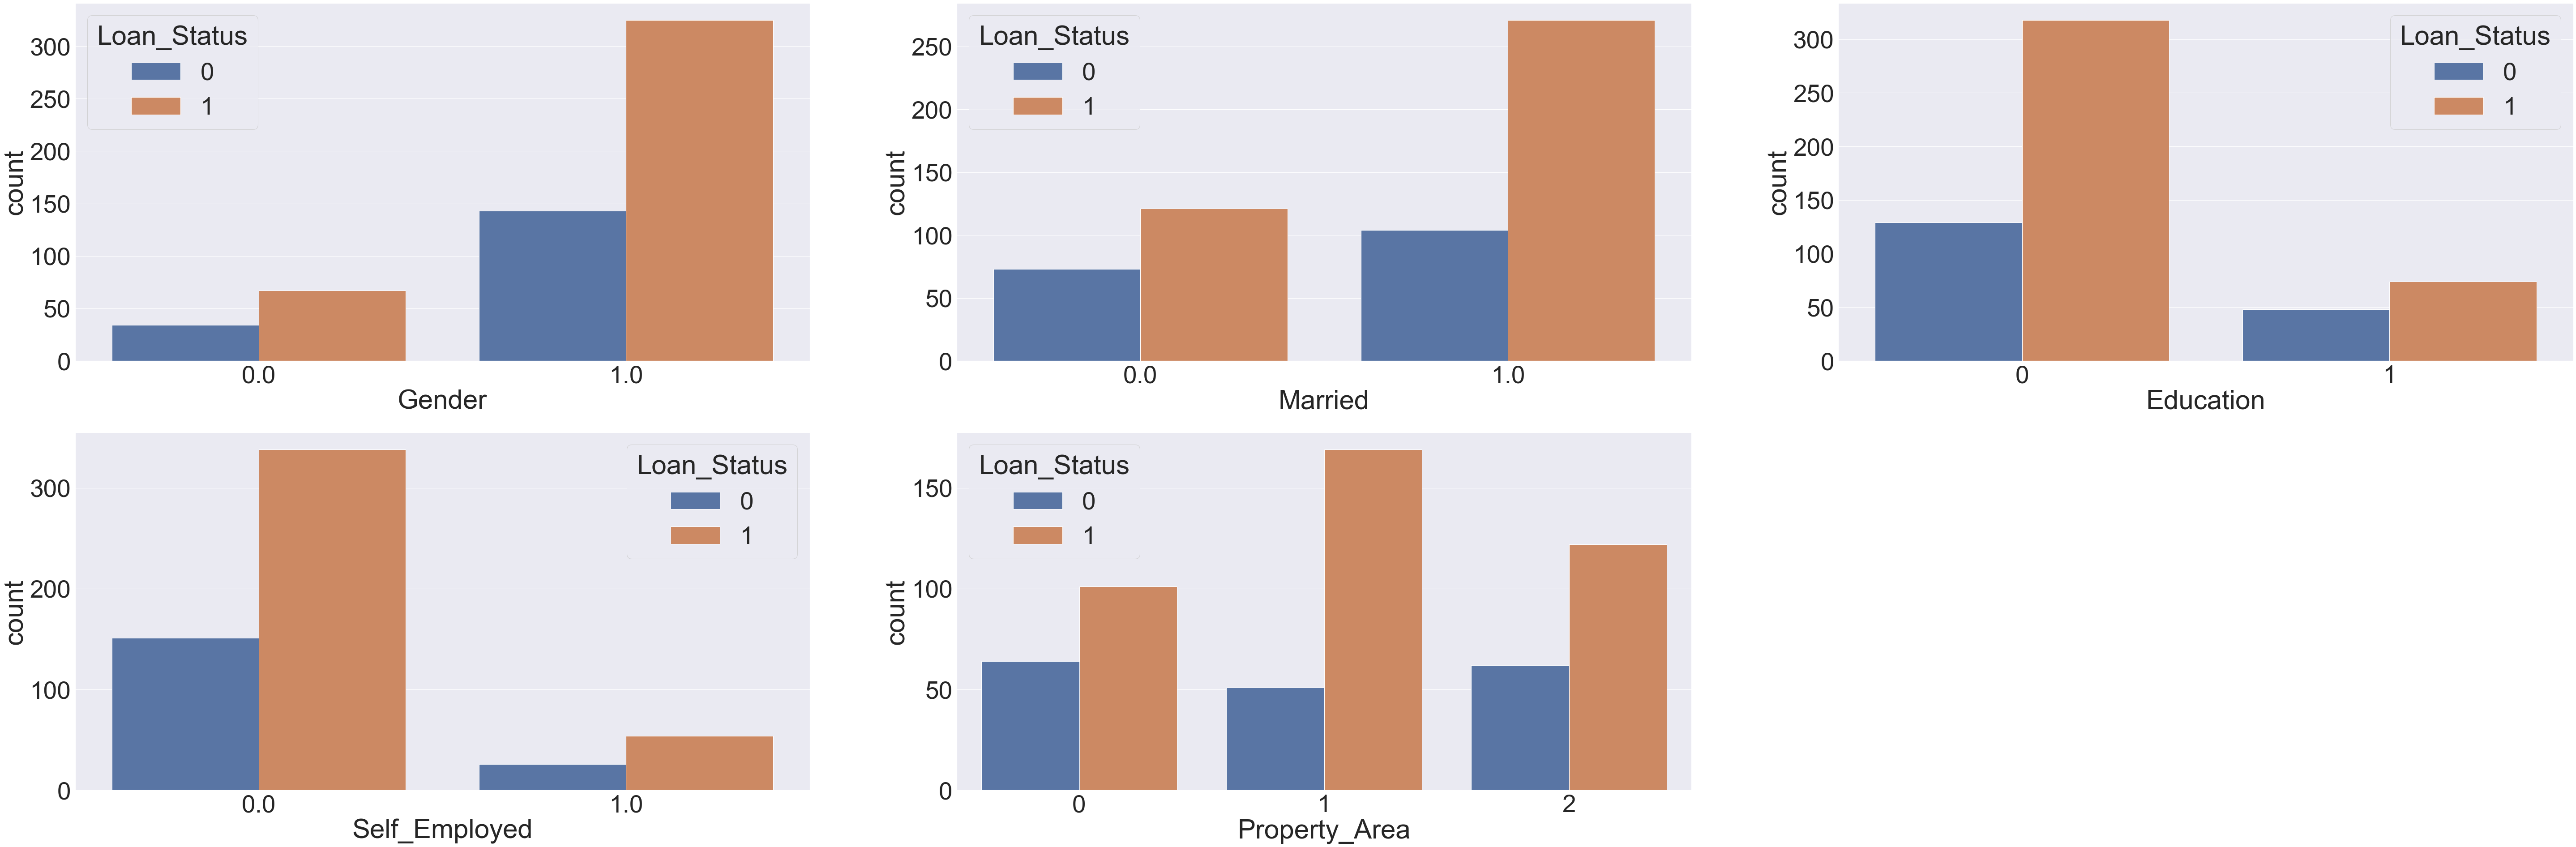

In [19]:
plt.figure(figsize = (100, 50))
sns.set(font_scale = 5)
plt.subplot(331)
sns.countplot(df_train['Gender'],hue=df_train['Loan_Status'])

plt.subplot(332)
sns.countplot(df_train['Married'],hue=df_train['Loan_Status'])

plt.subplot(333)
sns.countplot(df_train['Education'],hue=df_train['Loan_Status'])

plt.subplot(334)
sns.countplot(df_train['Self_Employed'],hue=df_train['Loan_Status'])

plt.subplot(335)
sns.countplot(df_train['Property_Area'],hue=df_train['Loan_Status'])

In [24]:
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1.0,0.0,0,0,0.0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,1.0,1.0,1,0,0.0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,1.0,1.0,0,0,1.0,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,1.0,1.0,0,1,0.0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,1.0,0.0,0,0,0.0,6000,0.0,141.000000,360.0,1.0,2,1


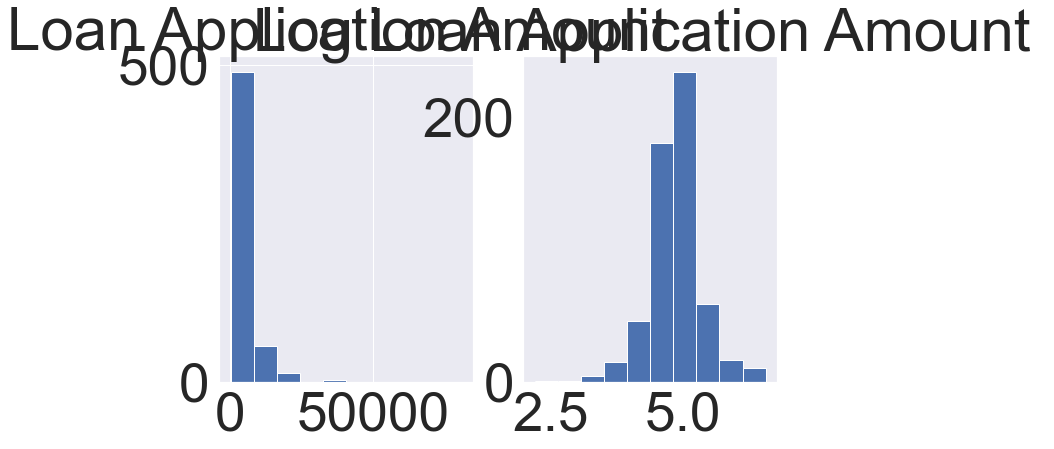

In [23]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)


df_train['ApplicantIncome'].hist(bins=10)
plt.title("Loan Application Amount ")

plt.subplot(1, 2, 2)
plt.grid()
plt.hist(np.log(df_train['LoanAmount']))
plt.title("Log Loan Application Amount ")

plt.show()

<AxesSubplot:>

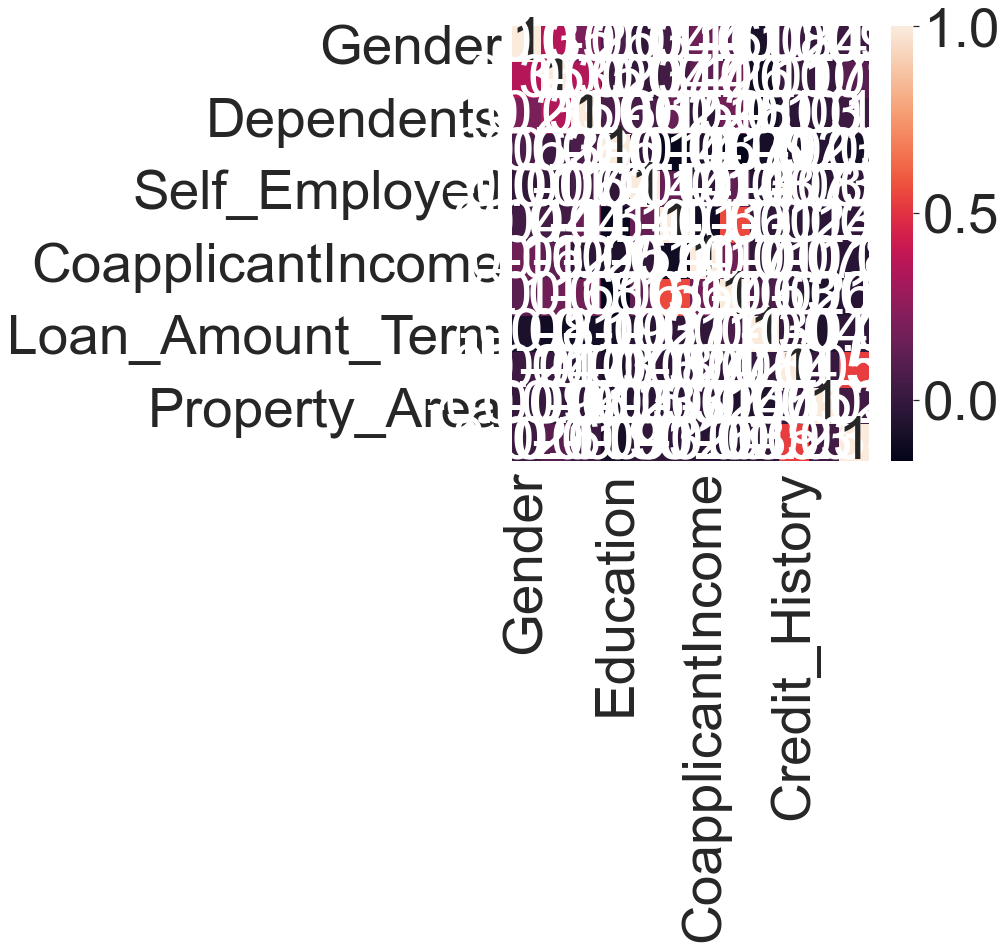

In [27]:
plt.figure(figsize=(8,8))
sns.heatmap(df_train.corr(), annot=True)

In this heatmap, we can clearly seen the relation between two variables